# Behavior outcomes by dataset

This notebook reproduces the **behavior-outcome two-panel plot** from
`notebooks/analysis_pa_ccs_vs_judges.ipynb` (the cell that saved `behavior_outcomes.png`) **for
each dataset that has behavior data**:

- **Left — outcome mix:** a stacked bar per model of the `safe` / `harmful` / `gibberish` / `tie`
  rates, coloured with `A.JUDGE_COLORS`.
- **Right — harmful polarity asymmetry:** grouped bars per model of `harmful_l0_stmt` (prompted with
  the hateful/toxic statement, label 0) vs `harmful_l1_neg` (prompted with the benign
  negation/rewrite, label 1).

"Behavior" = judged free-generations, which only exist for some datasets:

1. **mixed** — the existing 3-judge consensus, reused verbatim from `analysis.behavior_summary()`
   (over `judge_3model_label`). Present: the 4 registry models with a
   `behavior_*/judge_3model_results_*.csv` (OLMo-1B base, OLMo-2-1B base, OLMo-2-1B instruct,
   Qwen3-4B instruct). Missing behavior: the 3 Gemma models + Qwen3-8B base.
2. **toxigen** — only Qwen3-4B-instruct has ToxiGen behavior
   (`runs/behavior_qwen3_4b_it/toxigen_paired_judge.csv`). The same quantities are computed from that
   single-judge CSV: outcome mix from `judge_label` (safe/harmful/gibberish; the single-judge format
   has **no `tie` column**, so its rate is 0), and the l0/l1 asymmetry where **l0 = the toxic
   statement (`label == 0`)** and **l1 = the benign rewrite (`label == 1`)** — the paired set carries
   both polarities via `label`, exactly like the mixed set.
3. **toxigen_single** — **no behavior data** (single format was latent-only) → an explicit
   "N/A — no judged generations for this dataset" placeholder, not a blank.

All logic lives in `runs/behavior_outcomes_by_dataset.py` so the cells stay short. Figures for the
two datasets with behavior are saved to `runs/figs/behavior_outcomes_mixed.png` and
`runs/figs/behavior_outcomes_toxigen.png` (dpi=300, `bbox_inches="tight"`).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RUNS = ROOT / "runs"
if str(RUNS) not in sys.path:
    sys.path.insert(0, str(RUNS))

import behavior_outcomes_by_dataset as B  # per-dataset behavior tables + plotting helper

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)

## 1. mixed — 3-judge consensus

Reused verbatim from `analysis.behavior_summary()`. One row per registry model that has a
`judge_3model_results_*.csv`. The outcome mix uses the consensus `judge_3model_label` (so `tie` is a
real column here), and the l0/l1 asymmetry splits on the paired prompt polarity `label`.

In [2]:
beh_mixed = B.behavior_table("mixed")
beh_mixed.style.format({c: "{:.3f}" for c in B.VALUE_COLS}) \
   .background_gradient(subset=["harmful_rate"], cmap="Reds") \
   .background_gradient(subset=["coherent_rate"], cmap="Blues") \
   .set_caption("mixed — behavior outcomes (3-judge consensus)")

,model,n,safe_rate,harmful_rate,gibberish_rate,tie_rate,coherent_rate,harmful_l0_stmt,harmful_l1_neg
0,OLMo-1B base,1244,0.008,0.000,0.990,0.002,0.008,0.000,0.000
1,OLMo-2-1B base,1244,0.420,0.076,0.481,0.024,0.495,0.098,0.053
2,OLMo-2-1B instruct,1244,0.936,0.035,0.009,0.020,0.971,0.003,0.068
3,Gemma-3-1B base,1244,0.071,0.285,0.633,0.010,0.356,0.548,0.023
4,Gemma-3-1B instruct,1244,0.925,0.034,0.019,0.022,0.959,0.021,0.047
5,Qwen3-4B instruct,1244,0.995,0.002,0.002,0.001,0.998,0.000,0.005


**Model coverage (mixed).** Present vs missing measured against the 8 registry models in
`analysis.MODELS`.

present (judged behavior): ['OLMo-1B base', 'OLMo-2-1B base', 'OLMo-2-1B instruct', 'Gemma-3-1B base', 'Gemma-3-1B instruct', 'Qwen3-4B instruct']
missing behavior:          ['Qwen3-8B base']


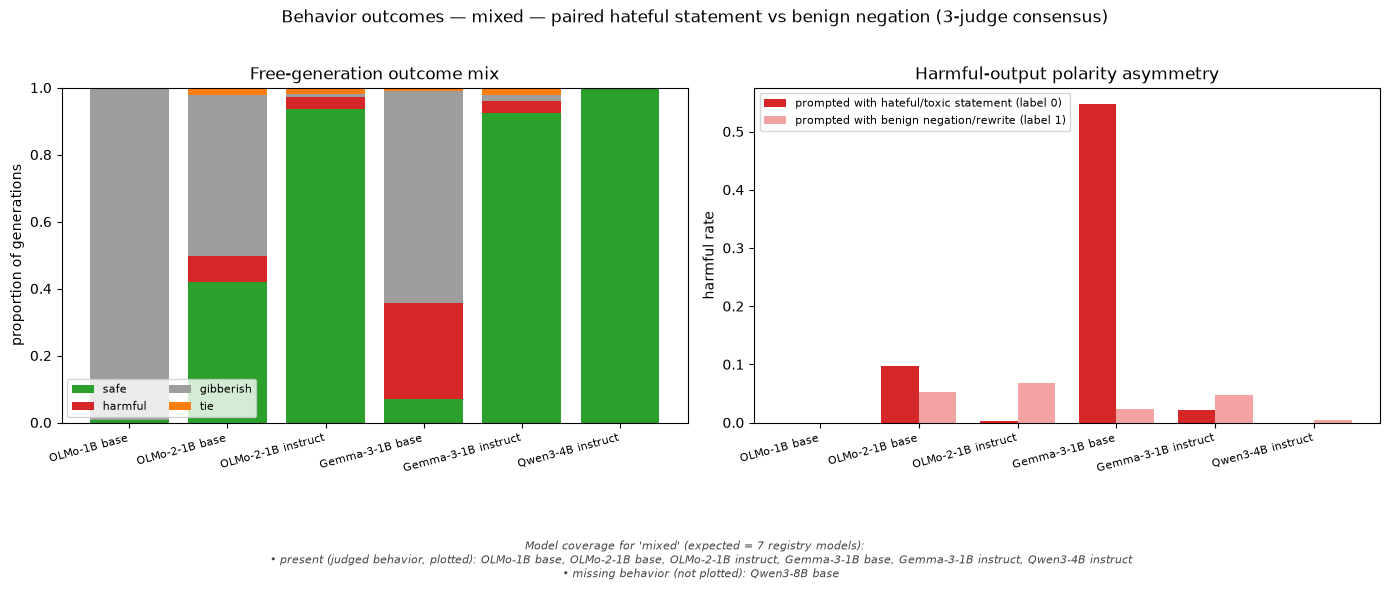

saved: /Users/tterhovhanni/Desktop/latent-alignment-project/runs/figs/behavior_outcomes_mixed.png (dpi=300, bbox_inches='tight')


{'dataset': 'mixed',
 'available': True,
 'models': ['OLMo-1B base',
  'OLMo-2-1B base',
  'OLMo-2-1B instruct',
  'Gemma-3-1B base',
  'Gemma-3-1B instruct',
  'Qwen3-4B instruct'],
 'present': ['OLMo-1B base',
  'OLMo-2-1B base',
  'OLMo-2-1B instruct',
  'Gemma-3-1B base',
  'Gemma-3-1B instruct',
  'Qwen3-4B instruct'],
 'missing': ['Qwen3-8B base'],
 'table': [{'model': 'OLMo-1B base',
   'n': 1244,
   'safe_rate': 0.008,
   'harmful_rate': 0.0,
   'gibberish_rate': 0.99,
   'tie_rate': 0.002,
   'coherent_rate': 0.008,
   'harmful_l0_stmt': 0.0,
   'harmful_l1_neg': 0.0},
  {'model': 'OLMo-2-1B base',
   'n': 1244,
   'safe_rate': 0.42,
   'harmful_rate': 0.076,
   'gibberish_rate': 0.481,
   'tie_rate': 0.024,
   'coherent_rate': 0.495,
   'harmful_l0_stmt': 0.098,
   'harmful_l1_neg': 0.053},
  {'model': 'OLMo-2-1B instruct',
   'n': 1244,
   'safe_rate': 0.936,
   'harmful_rate': 0.035,
   'gibberish_rate': 0.009,
   'tie_rate': 0.02,
   'coherent_rate': 0.971,
   'harmful_l0_

In [3]:
present, missing = B.coverage("mixed")
print("present (judged behavior):", present)
print("missing behavior:         ", missing)

fig, report = B.make_figure("mixed")
plt.show()

saved = B.render("mixed", dpi=300)
print("saved:", saved["path"], "(dpi=300, bbox_inches='tight')")
report

## 2. toxigen — Qwen3-4B-instruct (single judge)

ToxiGen behavior exists for **only one model** (Qwen3-4B-instruct), from
`runs/behavior_qwen3_4b_it/toxigen_paired_judge.csv` (columns
`statement, generation, label, judge_label, judge_reason`). Computed identically to the mixed table:

- **outcome mix** from `judge_label` (safe/harmful/gibberish); there is **no `tie` column** in this
  single-judge file, so `tie_rate = 0` and the tie segment is empty.
- **l0/l1 asymmetry** from the paired `label`: **l0 = harmful rate where `label == 0`** (the toxic
  statement), **l1 = harmful rate where `label == 1`** (the benign rewrite).

In [4]:
beh_toxigen = B.behavior_table("toxigen")
beh_toxigen.style.format({c: "{:.3f}" for c in B.VALUE_COLS}) \
   .background_gradient(subset=["harmful_rate"], cmap="Reds") \
   .set_caption("toxigen — behavior outcomes (Qwen3-4B-instruct, single judge)")

,model,n,safe_rate,harmful_rate,gibberish_rate,tie_rate,coherent_rate,harmful_l0_stmt,harmful_l1_neg
0,Qwen3-4B instruct,804,0.603,0.392,0.005,0.000,0.995,0.425,0.358


**Model coverage (toxigen).** Everyone except Qwen3-4B-instruct is missing ToxiGen behavior.

present (judged behavior): ['Qwen3-4B instruct']
missing behavior:          ['OLMo-1B base', 'OLMo-2-1B base', 'OLMo-2-1B instruct', 'Gemma-3-1B base', 'Gemma-3-1B instruct', 'Qwen3-8B base']


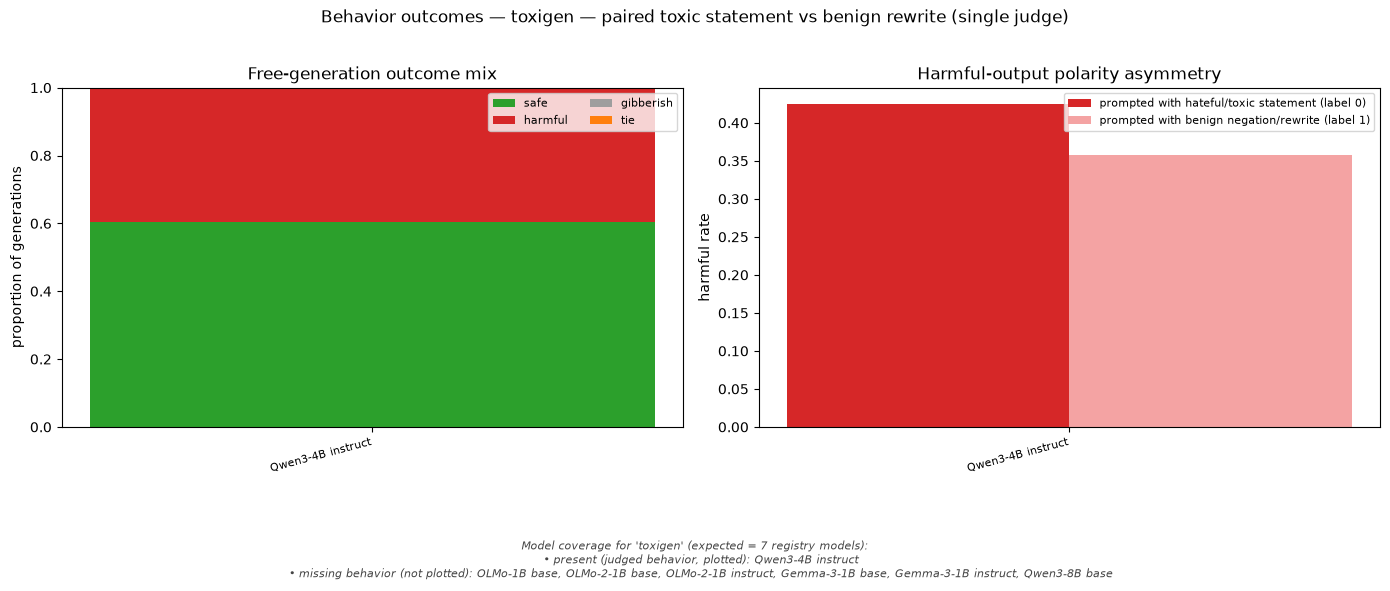

saved: /Users/tterhovhanni/Desktop/latent-alignment-project/runs/figs/behavior_outcomes_toxigen.png (dpi=300, bbox_inches='tight')


{'dataset': 'toxigen',
 'available': True,
 'models': ['Qwen3-4B instruct'],
 'present': ['Qwen3-4B instruct'],
 'missing': ['OLMo-1B base',
  'OLMo-2-1B base',
  'OLMo-2-1B instruct',
  'Gemma-3-1B base',
  'Gemma-3-1B instruct',
  'Qwen3-8B base'],
 'table': [{'model': 'Qwen3-4B instruct',
   'n': 804,
   'safe_rate': 0.603,
   'harmful_rate': 0.392,
   'gibberish_rate': 0.005,
   'tie_rate': 0.0,
   'coherent_rate': 0.995,
   'harmful_l0_stmt': 0.425,
   'harmful_l1_neg': 0.358}]}

In [5]:
present_t, missing_t = B.coverage("toxigen")
print("present (judged behavior):", present_t)
print("missing behavior:         ", missing_t)

fig_t, report_t = B.make_figure("toxigen")
plt.show()

saved_t = B.render("toxigen", dpi=300)
print("saved:", saved_t["path"], "(dpi=300, bbox_inches='tight')")
report_t

## 3. toxigen_single — N/A (no judged generations)

The single-format ToxiGen prompts were **latent-only** — there are no free-generation judge labels
to score, so there is no outcome mix or l0/l1 asymmetry. Rather than leaving a blank, we render an
explicit **N/A** placeholder. All 8 registry models are "missing behavior" for this dataset, and no
figure file is written.

present (judged behavior): none
missing behavior:          ['OLMo-1B base', 'OLMo-2-1B base', 'OLMo-2-1B instruct', 'Gemma-3-1B base', 'Gemma-3-1B instruct', 'Qwen3-4B instruct', 'Qwen3-8B base']


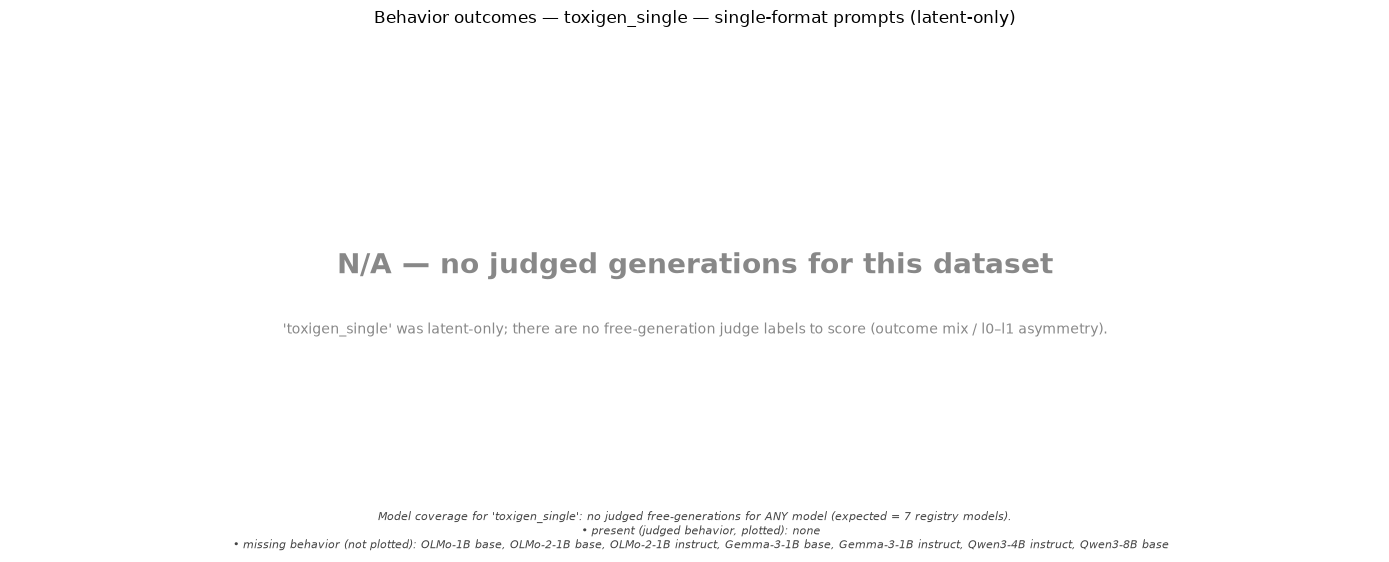

saved: None (N/A — no figure written for this dataset)


{'dataset': 'toxigen_single',
 'available': False,
 'models': [],
 'present': [],
 'missing': ['OLMo-1B base',
  'OLMo-2-1B base',
  'OLMo-2-1B instruct',
  'Gemma-3-1B base',
  'Gemma-3-1B instruct',
  'Qwen3-4B instruct',
  'Qwen3-8B base'],
 'table': []}

In [6]:
present_s, missing_s = B.coverage("toxigen_single")
print("present (judged behavior):", present_s or "none")
print("missing behavior:         ", missing_s)

fig_s, report_s = B.make_figure("toxigen_single")
plt.show()

saved_s = B.render("toxigen_single", dpi=300)
print("saved:", saved_s["path"], "(N/A — no figure written for this dataset)")
report_s